<a href="https://colab.research.google.com/github/123321juliocesar/Desarrollo2/blob/main/Autos_Randond_forest_regresion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MODELO DE PREDICCION PARA EL CONSUMO DE COMBUSTIBLE CON SVR

##ENTENDIMIENTO DE NEGOCION

##ENTENDIMIENTO DE LOS DATOS

###Coleccion o lectura de datos

In [1]:
from google.colab import files
import pandas as pd
import numpy as np

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:

# DEFINICIÓN DE LOS NOMBRES DE LAS COLUMNAS


columnas = [
    "mpg",
    "cylinders",
    "displacement",
    "horsepower",
    "weight",
    "acceleration",
    "model_year",
    "origin",
    "car_name"
]

In [5]:

# Cargar el dataset Auto MPG
df_autos = pd.read_csv(
    "/content/drive/MyDrive/Datasets/auto-mpg.data-original",  # Ruta exacta del archivo
    sep=r"\s+",                         # Uno o más espacios
    names=columnas,                     # Nombres de las columnas
    na_values="?",                      # Convertir ? en NaN
    quotechar='"'                       # Mantener completo el nombre del automóvil
)

# Verificar la carga
print("Dataset cargado correctamente")
print("Filas:", df_autos.shape[0])
print("Columnas:", df_autos.shape[1])

# Mostrar las primeras filas
df_autos.head()

Dataset cargado correctamente
Filas: 406
Columnas: 9


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,car_name
0,18.0,8.0,307.0,130.0,3504.0,12.0,70.0,1.0,chevrolet chevelle malibu
1,15.0,8.0,350.0,165.0,3693.0,11.5,70.0,1.0,buick skylark 320
2,18.0,8.0,318.0,150.0,3436.0,11.0,70.0,1.0,plymouth satellite
3,16.0,8.0,304.0,150.0,3433.0,12.0,70.0,1.0,amc rebel sst
4,17.0,8.0,302.0,140.0,3449.0,10.5,70.0,1.0,ford torino


###descripcion de datos


In [6]:
print("Cantidad de registros:", df_autos.shape[0])
print("Cantidad de columnas:", df_autos.shape[1])

Cantidad de registros: 406
Cantidad de columnas: 9


In [7]:
df_autos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 406 entries, 0 to 405
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     406 non-null    float64
 2   displacement  406 non-null    float64
 3   horsepower    400 non-null    float64
 4   weight        406 non-null    float64
 5   acceleration  406 non-null    float64
 6   model_year    406 non-null    float64
 7   origin        406 non-null    float64
 8   car_name      406 non-null    object 
dtypes: float64(8), object(1)
memory usage: 28.7+ KB


In [8]:
# Mostrar los nombres de las columnas
print(df_autos.columns.tolist())

['mpg', 'cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'model_year', 'origin', 'car_name']


In [9]:
# Identificar los tipos de datos
df_autos.dtypes

,0
mpg,float64
cylinders,float64
displacement,float64
horsepower,float64
weight,float64
acceleration,float64
model_year,float64
origin,float64
car_name,object


###Exploracion de datos

In [10]:
df_autos.describe().T

,count,mean,std,min,25%,50%,75%,max
mpg,398.0,23.514573,7.815984,9.0,17.50,23.0,29.000,46.6
cylinders,406.0,5.475369,1.712160,3.0,4.00,4.0,8.000,8.0
displacement,406.0,194.779557,104.922458,68.0,105.00,151.0,302.000,455.0
horsepower,400.0,105.082500,38.768779,46.0,75.75,95.0,130.000,230.0
weight,406.0,2979.413793,847.004328,1613.0,2226.50,2822.5,3618.250,5140.0
acceleration,406.0,15.519704,2.803359,8.0,13.70,15.5,17.175,24.8
model_year,406.0,75.921182,3.748737,70.0,73.00,76.0,79.000,82.0
origin,406.0,1.568966,0.797479,1.0,1.00,1.0,2.000,3.0


In [11]:
# Estadísticas de las variables categóricas
df_autos.describe(include="object").T

,count,unique,top,freq
car_name,406,312,ford pinto,6


In [12]:
# Número de valores únicos de cada columna
df_autos.nunique().sort_values()

,0
origin,3
cylinders,5
model_year,13
displacement,83
horsepower,93
acceleration,96
mpg,129
car_name,312
weight,356


In [13]:
for columna in df_autos.columns:
    print(f"\n===== {columna} =====")
    print(df_autos[columna].unique())


===== mpg =====
[18.  15.  16.  17.  14.   nan 24.  22.  21.  27.  26.  25.  10.  11.
  9.  28.  19.  12.  13.  23.  30.  31.  35.  20.  29.  32.  33.  17.5
 15.5 14.5 22.5 24.5 18.5 29.5 26.5 16.5 31.5 36.  25.5 33.5 20.5 30.5
 21.5 43.1 36.1 32.8 39.4 19.9 19.4 20.2 19.2 25.1 20.6 20.8 18.6 18.1
 17.7 27.5 27.2 30.9 21.1 23.2 23.8 23.9 20.3 21.6 16.2 19.8 22.3 17.6
 18.2 16.9 31.9 34.1 35.7 27.4 25.4 34.2 34.5 31.8 37.3 28.4 28.8 26.8
 41.5 38.1 32.1 37.2 26.4 24.3 19.1 34.3 29.8 31.3 37.  32.2 46.6 27.9
 40.8 44.3 43.4 36.4 44.6 40.9 33.8 32.7 23.7 23.6 32.4 26.6 25.8 23.5
 39.1 39.  35.1 32.3 37.7 34.7 34.4 29.9 33.7 32.9 31.6 28.1 30.7 24.2
 22.4 34.  38.  44. ]

===== cylinders =====
[8. 4. 6. 3. 5.]

===== displacement =====
[307.  350.  318.  304.  302.  429.  454.  440.  455.  390.  133.  351.
 383.  360.  340.  400.  113.  198.  199.  200.   97.  110.  107.  104.
 121.  140.   98.  232.  225.  250.  258.  122.  116.   79.   88.   71.
  72.   91.   97.5  70.  120.   96.  108.

In [14]:

print("Valores nulos antes de la imputación:")
print(df_autos.isnull().sum()[df_autos.isnull().sum() > 0])

Valores nulos antes de la imputación:
mpg           8
horsepower    6
dtype: int64


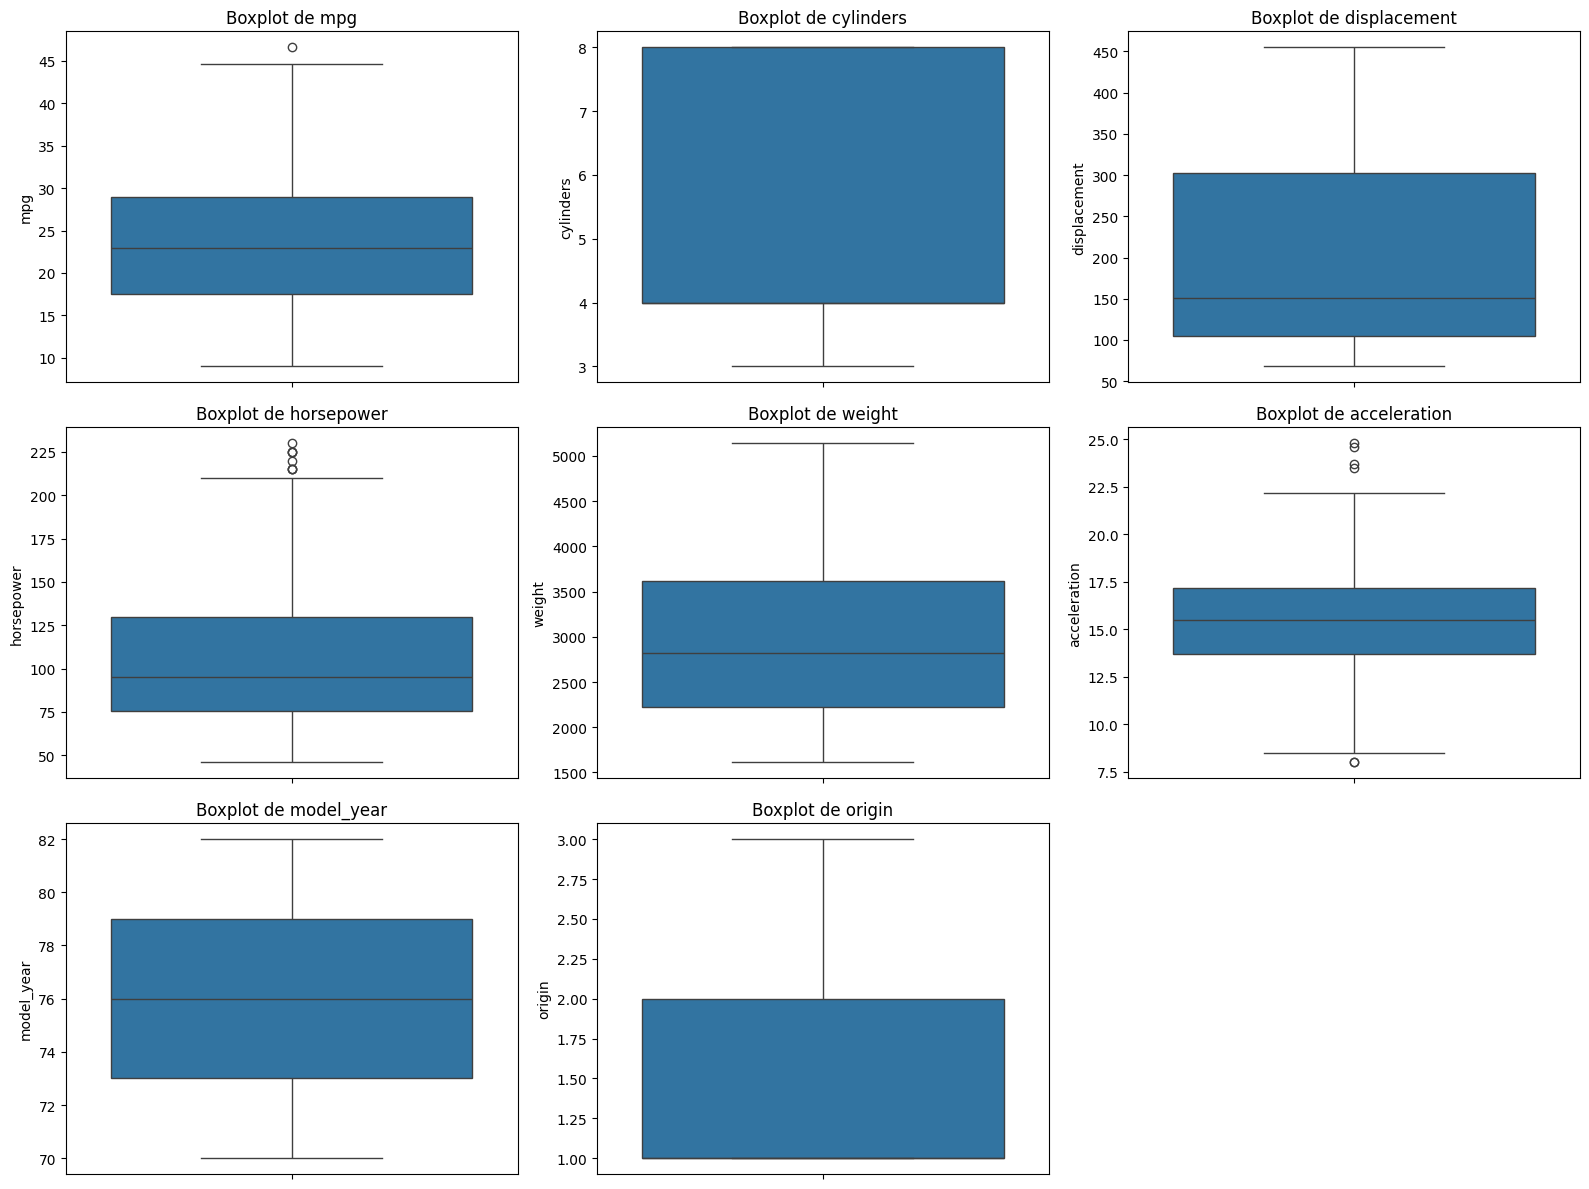

In [15]:
# BOXPLOT DE TODAS LAS VARIABLES NUMÉRICAS

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math

# Seleccionar únicamente las columnas numéricas
columnas_numericas = df_autos.select_dtypes(include=np.number).columns

# Cantidad de columnas por fila
columnas_grafico = 3

# Calcular el número de filas necesarias
filas_grafico = math.ceil(len(columnas_numericas) / columnas_grafico)

# Crear los gráficos
plt.figure(figsize=(16, 4 * filas_grafico))

for i, columna in enumerate(columnas_numericas):
    plt.subplot(filas_grafico, columnas_grafico, i + 1)

    sns.boxplot(
        y=df_autos[columna]
    )

    plt.title(f"Boxplot de {columna}")
    plt.ylabel(columna)

plt.tight_layout()
plt.show()

##PREPARACION DE DATOS

###Seleccion de datos

In [16]:
# Columnas seleccionadas para el modelado
columnas_seleccionadas = [
    "mpg",
    "cylinders",
    "displacement",
    "horsepower",
    "weight",
    "acceleration",
    "model_year",
    "origin"
]

df_modelo = df_autos[columnas_seleccionadas].copy()

print("Dimensiones del dataset seleccionado:", df_modelo.shape)
df_modelo.head()

Dimensiones del dataset seleccionado: (406, 8)


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin
0,18.0,8.0,307.0,130.0,3504.0,12.0,70.0,1.0
1,15.0,8.0,350.0,165.0,3693.0,11.5,70.0,1.0
2,18.0,8.0,318.0,150.0,3436.0,11.0,70.0,1.0
3,16.0,8.0,304.0,150.0,3433.0,12.0,70.0,1.0
4,17.0,8.0,302.0,140.0,3449.0,10.5,70.0,1.0


In [17]:
print("Columna eliminada del modelado: car_name")

Columna eliminada del modelado: car_name


###Limpieza de datos

In [18]:
df_modelo['mpg'].fillna(df_modelo['mpg'].median(), inplace=True)
df_modelo['horsepower'].fillna(df_modelo['horsepower'].median(), inplace=True)

print("Valores nulos después de la imputación:")
print(df_modelo.isnull().sum())

Valores nulos después de la imputación:
mpg             0
cylinders       0
displacement    0
horsepower      0
weight          0
acceleration    0
model_year      0
origin          0
dtype: int64


/tmp/ipykernel_1089/121075284.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_modelo['mpg'].fillna(df_modelo['mpg'].median(), inplace=True)
/tmp/ipykernel_1089/121075284.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplac

In [19]:
# Verificar valores nulos despues de la imputación
print("Valores nulos despues:")
print(df_modelo.isnull().sum())

Valores nulos antes:
mpg             0
cylinders       0
displacement    0
horsepower      0
weight          0
acceleration    0
model_year      0
origin          0
dtype: int64


In [20]:
df_modelo.isnull().sum()

,0
mpg,0
cylinders,0
displacement,0
horsepower,0
weight,0
acceleration,0
model_year,0
origin,0


###Construccion de datos

In [22]:
df_modelo.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin
0,18.0,8.0,307.0,130.0,3504.0,12.0,70.0,1.0
1,15.0,8.0,350.0,165.0,3693.0,11.5,70.0,1.0
2,18.0,8.0,318.0,150.0,3436.0,11.0,70.0,1.0
3,16.0,8.0,304.0,150.0,3433.0,12.0,70.0,1.0
4,17.0,8.0,302.0,140.0,3449.0,10.5,70.0,1.0


In [23]:
# Revisar los tipos de datos
df_modelo.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 406 entries, 0 to 405
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           406 non-null    float64
 1   cylinders     406 non-null    float64
 2   displacement  406 non-null    float64
 3   horsepower    406 non-null    float64
 4   weight        406 non-null    float64
 5   acceleration  406 non-null    float64
 6   model_year    406 non-null    float64
 7   origin        406 non-null    float64
dtypes: float64(8)
memory usage: 25.5 KB


In [24]:
# Crear una copia del dataset limpio
df_construido_autos = df_modelo.copy()

# Crear relación entre potencia y peso
df_construido_autos["power_weight_ratio"] = (
    df_construido_autos["horsepower"] / df_construido_autos["weight"]
)

# Crear desplazamiento por cilindro
df_construido_autos["displacement_per_cylinder"] = (
    df_construido_autos["displacement"] / df_construido_autos["cylinders"]
)

# Mostrar el resultado
df_construido_autos.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,power_weight_ratio,displacement_per_cylinder
0,18.0,8.0,307.0,130.0,3504.0,12.0,70.0,1.0,0.037100,38.375
1,15.0,8.0,350.0,165.0,3693.0,11.5,70.0,1.0,0.044679,43.750
2,18.0,8.0,318.0,150.0,3436.0,11.0,70.0,1.0,0.043655,39.750
3,16.0,8.0,304.0,150.0,3433.0,12.0,70.0,1.0,0.043694,38.000
4,17.0,8.0,302.0,140.0,3449.0,10.5,70.0,1.0,0.040591,37.750


In [25]:
# Convertir origin en variables binarias
df_construido_autos = pd.get_dummies(
    df_construido_autos,
    columns=["origin"],
    prefix="origin",
    drop_first=True,
    dtype=int
)

df_construido_autos.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,power_weight_ratio,displacement_per_cylinder,origin_2.0,origin_3.0
0,18.0,8.0,307.0,130.0,3504.0,12.0,70.0,0.037100,38.375,0,0
1,15.0,8.0,350.0,165.0,3693.0,11.5,70.0,0.044679,43.750,0,0
2,18.0,8.0,318.0,150.0,3436.0,11.0,70.0,0.043655,39.750,0,0
3,16.0,8.0,304.0,150.0,3433.0,12.0,70.0,0.043694,38.000,0,0
4,17.0,8.0,302.0,140.0,3449.0,10.5,70.0,0.040591,37.750,0,0


In [26]:
for columna in df_construido_autos.columns:
    print(f"\n===== {columna} =====")
    print(df_construido_autos[columna].unique())


===== mpg =====
[18.  15.  16.  17.  14.  23.  24.  22.  21.  27.  26.  25.  10.  11.
  9.  28.  19.  12.  13.  30.  31.  35.  20.  29.  32.  33.  17.5 15.5
 14.5 22.5 24.5 18.5 29.5 26.5 16.5 31.5 36.  25.5 33.5 20.5 30.5 21.5
 43.1 36.1 32.8 39.4 19.9 19.4 20.2 19.2 25.1 20.6 20.8 18.6 18.1 17.7
 27.5 27.2 30.9 21.1 23.2 23.8 23.9 20.3 21.6 16.2 19.8 22.3 17.6 18.2
 16.9 31.9 34.1 35.7 27.4 25.4 34.2 34.5 31.8 37.3 28.4 28.8 26.8 41.5
 38.1 32.1 37.2 26.4 24.3 19.1 34.3 29.8 31.3 37.  32.2 46.6 27.9 40.8
 44.3 43.4 36.4 44.6 40.9 33.8 32.7 23.7 23.6 32.4 26.6 25.8 23.5 39.1
 39.  35.1 32.3 37.7 34.7 34.4 29.9 33.7 32.9 31.6 28.1 30.7 24.2 22.4
 34.  38.  44. ]

===== cylinders =====
[8. 4. 6. 3. 5.]

===== displacement =====
[307.  350.  318.  304.  302.  429.  454.  440.  455.  390.  133.  351.
 383.  360.  340.  400.  113.  198.  199.  200.   97.  110.  107.  104.
 121.  140.   98.  232.  225.  250.  258.  122.  116.   79.   88.   71.
  72.   91.   97.5  70.  120.   96.  108.  155

In [27]:
# Verificar las columnas finales
print(df_construido_autos.columns.tolist())

# Verificar dimensiones
print("Filas:", df_construido_autos.shape[0])
print("Columnas:", df_construido_autos.shape[1])

# Verificar tipos de datos
print("\nTipos de datos:")
print(df_construido_autos.dtypes)

# Verificar valores nulos
print("\nValores nulos:")
print(df_construido_autos.isnull().sum())

# Verificar valores infinitos
import numpy as np

print(
    "\nCantidad de valores infinitos:",
    np.isinf(df_construido_autos.select_dtypes(include=np.number)).sum().sum()
)

['mpg', 'cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'model_year', 'power_weight_ratio', 'displacement_per_cylinder', 'origin_2.0', 'origin_3.0']
Filas: 406
Columnas: 11

Tipos de datos:
mpg                          float64
cylinders                    float64
displacement                 float64
horsepower                   float64
weight                       float64
acceleration                 float64
model_year                   float64
power_weight_ratio           float64
displacement_per_cylinder    float64
origin_2.0                     int64
origin_3.0                     int64
dtype: object

Valores nulos:
mpg                          0
cylinders                    0
displacement                 0
horsepower                   0
weight                       0
acceleration                 0
model_year                   0
power_weight_ratio           0
displacement_per_cylinder    0
origin_2.0                   0
origin_3.0                   0
dtype: int6

###Integracion de datos

###formateo de datos

In [28]:
# ============================================================
# FORMATEO DE DATOS
# ============================================================

df_formateado = df_construido_autos.copy()

print("Dimensión inicial:", df_formateado.shape)
df_formateado.head()

Dimensión inicial: (406, 11)


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,power_weight_ratio,displacement_per_cylinder,origin_2.0,origin_3.0
0,18.0,8.0,307.0,130.0,3504.0,12.0,70.0,0.037100,38.375,0,0
1,15.0,8.0,350.0,165.0,3693.0,11.5,70.0,0.044679,43.750,0,0
2,18.0,8.0,318.0,150.0,3436.0,11.0,70.0,0.043655,39.750,0,0
3,16.0,8.0,304.0,150.0,3433.0,12.0,70.0,0.043694,38.000,0,0
4,17.0,8.0,302.0,140.0,3449.0,10.5,70.0,0.040591,37.750,0,0


In [29]:
# Revisar los tipos de datos
print(df_formateado.dtypes)

mpg                          float64
cylinders                    float64
displacement                 float64
horsepower                   float64
weight                       float64
acceleration                 float64
model_year                   float64
power_weight_ratio           float64
displacement_per_cylinder    float64
origin_2.0                     int64
origin_3.0                     int64
dtype: object


In [30]:
# Mostrar columnas que no sean numéricas
columnas_no_numericas = df_formateado.select_dtypes(
    exclude="number"
).columns.tolist()

print("Columnas no numéricas:", columnas_no_numericas)

Columnas no numéricas: []


In [31]:
# Columnas que representan cantidades enteras
columnas_enteras = [
    "cylinders",
    "model_year",
    "origin_2.0",
    "origin_3.0"
]

for columna in columnas_enteras:
    if columna in df_formateado.columns:
        df_formateado[columna] = df_formateado[columna].astype(int)

In [32]:
# Columnas continuas
columnas_decimales = [
    "mpg",
    "displacement",
    "horsepower",
    "weight",
    "acceleration",
    "power_weight_ratio",
    "displacement_per_cylinder"
]

for columna in columnas_decimales:
    if columna in df_formateado.columns:
        df_formateado[columna] = df_formateado[columna].astype(float)

In [33]:
import numpy as np

# Verificar valores nulos
print("Valores nulos:")
print(df_formateado.isnull().sum())

# Verificar valores infinitos
cantidad_infinitos = np.isinf(
    df_formateado.select_dtypes(include=np.number)
).sum().sum()

print("\nValores infinitos:", cantidad_infinitos)

Valores nulos:
mpg                          0
cylinders                    0
displacement                 0
horsepower                   0
weight                       0
acceleration                 0
model_year                   0
power_weight_ratio           0
displacement_per_cylinder    0
origin_2.0                   0
origin_3.0                   0
dtype: int64

Valores infinitos: 0


## 4. MODELADO

In [34]:
# Variable objetivo
y = df_formateado["mpg"]

# Variables predictoras
X = df_formateado.drop(columns=["mpg"])

print("Dimensión de X:", X.shape)
print("Dimensión de y:", y.shape)

print("\nVariables predictoras:")
print(X.columns.tolist())

Dimensión de X: (406, 10)
Dimensión de y: (406,)

Variables predictoras:
['cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'model_year', 'power_weight_ratio', 'displacement_per_cylinder', 'origin_2.0', 'origin_3.0']


In [36]:
from sklearn.model_selection import train_test_split

In [37]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("DISEÑO DE PRUEBA")
print("----------------------------")
print("Total de registros:", len(df_formateado))
print("Registros de entrenamiento:", len(X_train))
print("Registros de prueba:", len(X_test))
print("Variables predictoras:", X_train.shape[1])

DISEÑO DE PRUEBA
----------------------------
Total de registros: 406
Registros de entrenamiento: 324
Registros de prueba: 82
Variables predictoras: 10


Para evaluar el rendimiento del modelo, el conjunto de datos fue dividido en dos subconjuntos. El 80 % de los registros se destinó al entrenamiento y el 20 % restante a la prueba. La división se realizó utilizando una semilla aleatoria de 42, con el propósito de garantizar la reproducibilidad del experimento. El conjunto de prueba se mantuvo separado durante el entrenamiento y fue utilizado únicamente para evaluar la capacidad de generalización del modelo.

##seleccion de modelos

In [35]:
from sklearn.ensemble import RandomForestRegressor

In [38]:
# Crear el modelo Random Forest Regressor
modelo_rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features=1.0,
    bootstrap=True,
    random_state=42,
    n_jobs=-1
)

print("Modelo configurado correctamente")

Modelo configurado correctamente


##Generar diseño de prueba

In [39]:
# Mostrar los parámetros del modelo
parametros_modelo = modelo_rf.get_params()

for parametro, valor in parametros_modelo.items():
    print(f"{parametro}: {valor}")

bootstrap: True
ccp_alpha: 0.0
criterion: squared_error
max_depth: None
max_features: 1.0
max_leaf_nodes: None
max_samples: None
min_impurity_decrease: 0.0
min_samples_leaf: 1
min_samples_split: 2
min_weight_fraction_leaf: 0.0
monotonic_cst: None
n_estimators: 100
n_jobs: -1
oob_score: False
random_state: 42
verbose: 0
warm_start: False


In [40]:
# Entrenar el modelo
modelo_rf.fit(X_train, y_train)

print("Modelo Random Forest entrenado correctamente")

Modelo Random Forest entrenado correctamente


In [41]:
print("Cantidad de árboles entrenados:", len(modelo_rf.estimators_))

Cantidad de árboles entrenados: 100


##Realizar predicciones

In [42]:
# Predicciones del conjunto de entrenamiento
y_pred_train = modelo_rf.predict(X_train)

# Predicciones del conjunto de prueba
y_pred_test = modelo_rf.predict(X_test)

print("Predicciones realizadas correctamente")

Predicciones realizadas correctamente


In [43]:
import pandas as pd

comparacion = pd.DataFrame({
    "MPG real": y_test.values,
    "MPG predicho": y_pred_test,
    "Error": y_test.values - y_pred_test
})

comparacion.head(10)

,MPG real,MPG predicho,Error
0,14.0,13.125,0.875
1,16.5,18.585,-2.085
2,20.2,18.330,1.870
3,11.0,13.052,-2.052
4,17.0,17.818,-0.818
5,13.0,12.875,0.125
6,26.0,24.165,1.835
7,43.4,36.241,7.159
8,33.5,28.843,4.657
9,20.8,20.609,0.191


#Evaluar el modelo

In [44]:
import numpy as np

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Métricas de entrenamiento
mae_train = mean_absolute_error(y_train, y_pred_train)
mse_train = mean_squared_error(y_train, y_pred_train)
rmse_train = np.sqrt(mse_train)
r2_train = r2_score(y_train, y_pred_train)

# Métricas de prueba
mae_test = mean_absolute_error(y_test, y_pred_test)
mse_test = mean_squared_error(y_test, y_pred_test)
rmse_test = np.sqrt(mse_test)
r2_test = r2_score(y_test, y_pred_test)

print("EVALUACIÓN DEL MODELO")
print("--------------------------------")
print("ENTRENAMIENTO")
print(f"MAE:  {mae_train:.4f}")
print(f"MSE:  {mse_train:.4f}")
print(f"RMSE: {rmse_train:.4f}")
print(f"R²:   {r2_train:.4f}")

print("\nPRUEBA")
print(f"MAE:  {mae_test:.4f}")
print(f"MSE:  {mse_test:.4f}")
print(f"RMSE: {rmse_test:.4f}")
print(f"R²:   {r2_test:.4f}")

EVALUACIÓN DEL MODELO
--------------------------------
ENTRENAMIENTO
MAE:  0.7898
MSE:  1.1909
RMSE: 1.0913
R²:   0.9798

PRUEBA
MAE:  2.1668
MSE:  9.3541
RMSE: 3.0585
R²:   0.8492


El modelo Random Forest Regressor presentó un rendimiento elevado. En el conjunto de prueba alcanzó un coeficiente de determinación de 0.8492, lo que indica que explica aproximadamente el 84.92 % de la variabilidad del consumo de combustible. Asimismo, obtuvo un MAE de 2.1668 mpg y un RMSE de 3.0585 mpg. Sin embargo, la diferencia entre el R² de entrenamiento y prueba fue de 0.1306, lo que evidencia un nivel leve a moderado de sobreajuste.